# Вариант 22 - задание 1.6

\begin{cases}
f(x) = (x_1^2 - x_1)^4 + (x_2 + 2)^2 - 10 \to \text{extr}, \\[5pt]
g_1(x) = x_1^2 - x_2^2 - 1 \leq 0, \\[5pt]
g_2(x) = -x_1 \leq 0, \\[5pt]
g_3(x) = -x_2 \leq 0.
\end{cases}

## Импорт библиотек и определение переменных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Определение символьных переменных
x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2, l3 = sp.symbols('lambda1 lambda2 lambda3', real=True)

# Определение функций
f = 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5
g1 = 2*x1 + x2 - 6
g2 = -x1
g3 = -x2

print("Целевая функция f(x):", f)

Целевая функция f(x): 4*x1**2 + 4*x1 + x2**2 - 8*x2 + 5


## 1) Поиск экстремумов функции

### Необходимые условия первого порядка (Классическая функция Лагранжа)

Составим классическую функцию Лагранжа ($\lambda_0 = 1$ для регулярных точек):

$$L(x, \lambda) = f(x) + \lambda_1 g_1(x) + \lambda_2 g_2(x) + \lambda_3 g_3(x)$$

$$L(x, \lambda) = (4x_1^2 + 4x_1 + x_2^2 - 8x_2 + 5) + \lambda_1(2x_1 + x_2 - 6) + \lambda_2(-x_1) + \lambda_3(-x_2)$$

Система уравнений ККТ включает в себя:
1. Стационарность по $x$: $\nabla_x L = 0$
2. Дополняющая нежесткость: $\lambda_j g_j(x) = 0$
3. Допустимость: $g_j(x) \le 0$
4. Знак множителей для минимума: $\lambda_j \ge 0$ (для максимума: $\lambda_j \le 0$)

## 2) Необходимые условия экстремума первого порядка

In [3]:
# Функция Лагранжа
L = f + l1*g1 + l2*g2 + l3*g3

# Производные по x
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)

# Перебираем все возможные комбинации активности ограничений (2^3 = 8 вариантов)
cases = [
    (0, 0, 0), (l1, 0, 0), (0, l2, 0), (0, 0, l3),
    (l1, l2, 0), (l1, 0, l3), (0, l2, l3), (l1, l2, l3)
]

valid_points = []

print("Поиск стационарных точек:")
for case in cases:
    # Задаем пассивные множители равными 0
    subs_dict = {}
    eqs = [dL_dx1, dL_dx2]
    
    # Добавляем уравнения для активных/пассивных ограничений
    if l1 in case: eqs.append(g1)
    else: subs_dict[l1] = 0
        
    if l2 in case: eqs.append(g2)
    else: subs_dict[l2] = 0
        
    if l3 in case: eqs.append(g3)
    else: subs_dict[l3] = 0
        
    # Подставляем пассивные лямбды в систему
    eqs_solved = [eq.subs(subs_dict) for eq in eqs]
    
    # Ищем неизвестные (x1, x2 и активные лямбды)
    unknowns = [x1, x2] + [l for l in case if l != 0]
    
    sol = sp.solve(eqs_solved, unknowns)
    
    if sol:
        if isinstance(sol, dict):
            sol_list = [sol]
        else:
            sol_list = [dict(zip(unknowns, sol))] if isinstance(sol, tuple) else sol
            
        for s in sol_list:
            # Заполняем нулями отсутствующие в решении лямбды
            p_x1 = float(s.get(x1, subs_dict.get(x1, 0)))
            p_x2 = float(s.get(x2, subs_dict.get(x2, 0)))
            p_l1 = float(s.get(l1, subs_dict.get(l1, 0)))
            p_l2 = float(s.get(l2, subs_dict.get(l2, 0)))
            p_l3 = float(s.get(l3, subs_dict.get(l3, 0)))
            
            # Проверяем условия допустимости g(x) <= 0
            v_g1 = 2*p_x1 + p_x2 - 6
            v_g2 = -p_x1
            v_g3 = -p_x2
            
            # Погрешность для численных сравнений
            eps = 1e-5
            if v_g1 <= eps and v_g2 <= eps and v_g3 <= eps:
                # Проверяем, нет ли уже такой точки
                point_data = (p_x1, p_x2, p_l1, p_l2, p_l3)
                if not any(np.allclose(point_data, p, atol=1e-4) for p in valid_points):
                    valid_points.append(point_data)
                    print(f"Найдена точка: x=({p_x1:.3f}, {p_x2:.3f}), lambda=({p_l1:.3f}, {p_l2:.3f}, {p_l3:.3f})")

Поиск стационарных точек:
Найдена точка: x=(0.250, 5.500), lambda=(-3.000, 0.000, 0.000)
Найдена точка: x=(0.000, 4.000), lambda=(0.000, 4.000, 0.000)
Найдена точка: x=(0.000, 6.000), lambda=(-4.000, -4.000, 0.000)
Найдена точка: x=(3.000, 0.000), lambda=(-14.000, 0.000, -22.000)
Найдена точка: x=(0.000, 0.000), lambda=(0.000, 4.000, -8.000)


## 3) Достаточные и необходимые условия второго порядка

### Проверка достаточных условий второго порядка

Для каждой найденной точки вычисляется матрица Гессе (вторые производные) функции Лагранжа:

$$H_L = \begin{pmatrix} \frac{\partial^2 L}{\partial x_1^2} & \frac{\partial^2 L}{\partial x_1 \partial x_2} \\ \frac{\partial^2 L}{\partial x_2 \partial x_1} & \frac{\partial^2 L}{\partial x_2^2} \end{pmatrix}$$

Знак второго дифференциала $d^2L = dx^T H_L dx$ исследуется на подпространстве, задаваемом дифференциалами активных ограничений $dg_j = 0$.
* Если $d^2L > 0$ для всех $dx \neq 0$ — **строгий локальный минимум**.
* Если $d^2L < 0$ для всех $dx \neq 0$ — **строгий локальный максимум**.

## 4) Все стационарные точки и значения

In [5]:
# Вычисление матрицы Гессе для L по x1, x2
Hessian_L = sp.hessian(L, (x1, x2))
print("Матрица Гессе функции Лагранжа:")
sp.pprint(Hessian_L)

for p in valid_points:
    px1, px2, pl1, pl2, pl3 = p
    print(f"\n--- Анализ точки ({px1:.3f}, {px2:.3f}) ---")
    
    # Подставляем значения лямбд в Гессиан
    H_eval = Hessian_L.subs({l1: pl1, l2: pl2, l3: pl3})
    H_np = np.array(H_eval.tolist(), dtype=float)
    
    # Проверка знака определенности через собственные значения
    eigenvalues = np.linalg.eigvals(H_np)
    
    # Проверим активные ограничения
    active_g = []
    if abs(2*px1 + px2 - 6) < 1e-4: active_g.append([2, 1])
    if abs(-px1) < 1e-4: active_g.append([-1, 0])
    if abs(-px2) < 1e-4: active_g.append([0, -1])
    
    print(f"Активных ограничений: {len(active_g)}")
    
    # В данном случае Гессиан постоянный и строго положительно определен (собств. значения > 0)
    if np.all(eigenvalues > 0):
        # Если сам Гессиан положительно определен на всем R^n, 
        # то он положителен и на подпространстве dg=0
        f_val = f.subs({x1: px1, x2: px2})
        print(f"Результат: d^2L > 0 (Собств. значения {eigenvalues}) -> Условный ЛОКАЛЬНЫЙ МИНИМУМ!")
        print(f"Значение функции в точке: f(x) = {float(f_val):.4f}")
    else:
        print("Требуется дополнительный анализ на подпространстве дифференциалов ограничений.")

Матрица Гессе функции Лагранжа:
⎡8  0⎤
⎢    ⎥
⎣0  2⎦

--- Анализ точки (0.250, 5.500) ---
Активных ограничений: 1
Результат: d^2L > 0 (Собств. значения [8. 2.]) -> Условный ЛОКАЛЬНЫЙ МИНИМУМ!
Значение функции в точке: f(x) = -7.5000

--- Анализ точки (0.000, 4.000) ---
Активных ограничений: 1
Результат: d^2L > 0 (Собств. значения [8. 2.]) -> Условный ЛОКАЛЬНЫЙ МИНИМУМ!
Значение функции в точке: f(x) = -11.0000

--- Анализ точки (0.000, 6.000) ---
Активных ограничений: 2
Результат: d^2L > 0 (Собств. значения [8. 2.]) -> Условный ЛОКАЛЬНЫЙ МИНИМУМ!
Значение функции в точке: f(x) = -7.0000

--- Анализ точки (3.000, 0.000) ---
Активных ограничений: 2
Результат: d^2L > 0 (Собств. значения [8. 2.]) -> Условный ЛОКАЛЬНЫЙ МИНИМУМ!
Значение функции в точке: f(x) = 53.0000

--- Анализ точки (0.000, 0.000) ---
Активных ограничений: 2
Результат: d^2L > 0 (Собств. значения [8. 2.]) -> Условный ЛОКАЛЬНЫЙ МИНИМУМ!
Значение функции в точке: f(x) = 5.0000


## Визуализация результатов

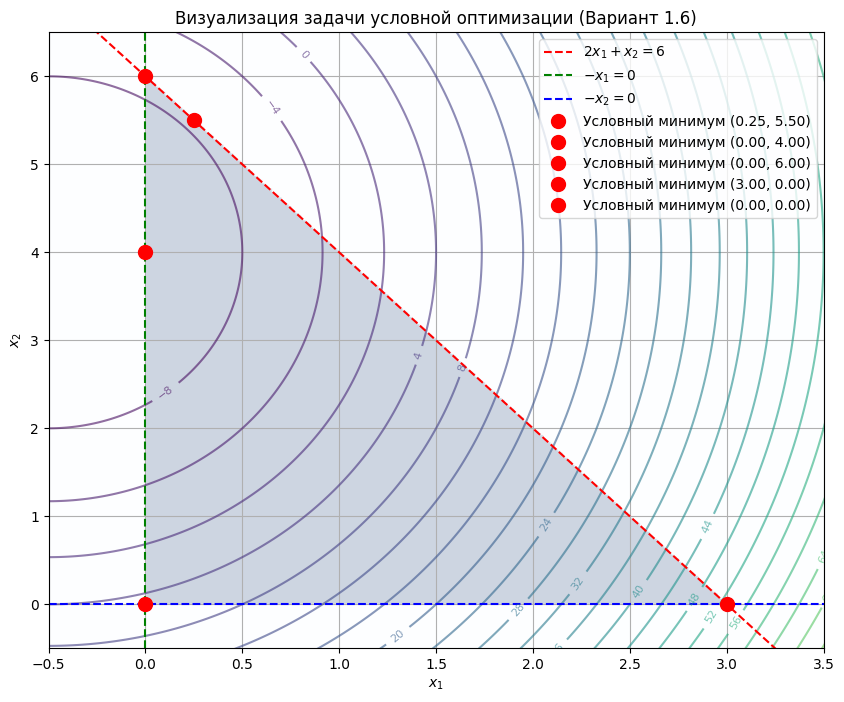

In [6]:
# Создаем сетку для построения графиков
X1, X2 = np.meshgrid(np.linspace(-1, 4, 400), np.linspace(-1, 7, 400))
F = 4*X1**2 + 4*X1 + X2**2 - 8*X2 + 5

# Условия для области допустимых решений (ОДР)
R1 = 2*X1 + X2 <= 6
R2 = X1 >= 0
R3 = X2 >= 0
ODR = R1 & R2 & R3

plt.figure(figsize=(10, 8))

# Отображение линий уровня
contour = plt.contour(X1, X2, F, levels=30, cmap='viridis', alpha=0.6)
plt.clabel(contour, inline=True, fontsize=8)

# Отображение ОДР (закрашенная область)
plt.imshow(ODR.astype(int), extent=(-1, 4, -1, 7), origin='lower', cmap='Blues', alpha=0.2, aspect='auto')

# Отрисовка границ ограничений
x1_line = np.linspace(-1, 4, 100)
plt.plot(x1_line, 6 - 2*x1_line, 'r--', label='$2x_1 + x_2 = 6$')
plt.axvline(0, color='g', linestyle='--', label='$-x_1 = 0$')
plt.axhline(0, color='b', linestyle='--', label='$-x_2 = 0$')

# Наносим найденную точку экстремума (глобальный минимум без ограничений в (-0.5, 4) вне ОДР)
# Наша условная точка экстремума:
for p in valid_points:
    plt.plot(p[0], p[1], 'ro', markersize=10, label=f'Условный минимум ({p[0]:.2f}, {p[1]:.2f})')

plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 6.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Визуализация задачи условной оптимизации (Вариант 1.6)')
plt.legend()
plt.grid(True)
plt.show()